# 1.4.4 Smoothing Images

## Kernel Convolution

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [3]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [4]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [5]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [6]:
img

array([[3, 9, 3, 5, 2, 6, 4, 1, 0, 3, 2, 9],
       [5, 6, 0, 2, 9, 4, 7, 9, 3, 4, 4, 1],
       [9, 4, 6, 8, 4, 8, 6, 0, 8, 3, 3, 6],
       [9, 7, 5, 6, 0, 0, 0, 0, 3, 0, 9, 9],
       [3, 6, 8, 1, 9, 1, 1, 8, 9, 3, 0, 5],
       [9, 0, 9, 7, 4, 3, 0, 3, 3, 8, 4, 4],
       [6, 7, 5, 3, 4, 2, 5, 8, 7, 7, 4, 0],
       [2, 8, 8, 3, 4, 4, 5, 0, 2, 2, 9, 0],
       [3, 3, 1, 6, 0, 0, 4, 9, 3, 6, 5, 0],
       [7, 4, 6, 7, 4, 6, 4, 0, 0, 6, 5, 0],
       [5, 1, 2, 9, 9, 7, 0, 1, 7, 9, 1, 6],
       [3, 9, 3, 0, 7, 4, 5, 1, 5, 1, 5, 0]])

In [7]:
h,w=img.shape

In [8]:
print(h,w)

12 12


In [9]:
#[*range(-2,3)]

In [10]:
dst = np.zeros((h,w),int)

In [11]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [12]:
img

array([[3, 9, 3, 5, 2, 6, 4, 1, 0, 3, 2, 9],
       [5, 6, 0, 2, 9, 4, 7, 9, 3, 4, 4, 1],
       [9, 4, 6, 8, 4, 8, 6, 0, 8, 3, 3, 6],
       [9, 7, 5, 6, 0, 0, 0, 0, 3, 0, 9, 9],
       [3, 6, 8, 1, 9, 1, 1, 8, 9, 3, 0, 5],
       [9, 0, 9, 7, 4, 3, 0, 3, 3, 8, 4, 4],
       [6, 7, 5, 3, 4, 2, 5, 8, 7, 7, 4, 0],
       [2, 8, 8, 3, 4, 4, 5, 0, 2, 2, 9, 0],
       [3, 3, 1, 6, 0, 0, 4, 9, 3, 6, 5, 0],
       [7, 4, 6, 7, 4, 6, 4, 0, 0, 6, 5, 0],
       [5, 1, 2, 9, 9, 7, 0, 1, 7, 9, 1, 6],
       [3, 9, 3, 0, 7, 4, 5, 1, 5, 1, 5, 0]])

In [13]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   6, -17, -14,  24, -14,   5,  25,  -9,   3,   6,   0],
       [  0, -12,   7,  14,  -9,  18,   9, -23,  23,  -3, -10,   0],
       [  0,   4,  -7,  10, -19,  -9,  -7, -11,  -5, -18,  24,   0],
       [  0,   6,  11, -26,  30,  -9,  -5,  19,  19,  -5, -21,   0],
       [  0, -31,  16,  11,  -7,   5, -12,  -7, -15,  15,   0,   0],
       [  0,   9,  -7,  -7,   3,  -8,   5,  17,   8,   7,  -4,   0],
       [  0,  12,  15,  -9,   5,   5,   7, -24,  -4, -16,  25,   0],
       [  0,  -4, -19,  13, -14, -14,  -2,  29,  -5,   8,   0,   0],
       [  0,  -1,  10,   3,  -6,   9,   6, -14, -16,   4,   8,   0],
       [  0, -16, -11,  18,   9,   9, -17,  -4,  13,  21, -21,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [23]:
img = cv2.imread('lena.png', 0)
img1 = cv2.imread('lena.png', 0)

In [15]:
h,w=img.shape

In [16]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [17]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [18]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [24]:
img1 = cv2.cvtColor(img1,cv2.COLOR_BGR2RGB)

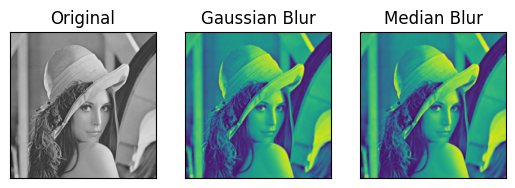

In [38]:
kernel=np.ones((5,5),np.float32)/25
blur = cv2.GaussianBlur(img,(5,5),0)
median = cv2.medianBlur(img,5)
dst=cv2.filter2D(img,-1,kernel)
plt.subplot(131),plt.imshow(img1 ),plt.title('Original')
plt.xticks([]),plt.yticks([])
plt.subplot(132),plt.imshow(blur),plt.title('Gaussian Blur')
plt.xticks([]),plt.yticks([])
plt.subplot(133),plt.imshow(median),plt.title('Median Blur')
plt.xticks([]),plt.yticks([])
plt.show()